# Sesi 4 - Feature Extraction ~ Edge (26/02/2026)

* [] Sobel -> turunan ke-1, buat nurunin grafik, sobel adalah algortima yang dipakai untuk nurunin turunan pertama, hanya 1 arah x/y
* [] Laplacian -> turunan ke-2, semua arah
* [] Canny -> multi tahap, paling bagusagus, tapi lambat karena complex

referensi : https://opencv.org/blog/edge-detection-using-opencv/ 

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# load image in grayscale
img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
print(img)


[[ 1  2  3 ... 40 41 49]
 [ 1  2  3 ... 40 36 39]
 [ 3  3  4 ... 37 31 31]
 ...
 [13 10 10 ... 15 15 14]
 [13  9  9 ... 16 16 15]
 [16 11  8 ... 17 17 16]]


Text(0.5, 1.0, 'Sobel Result')

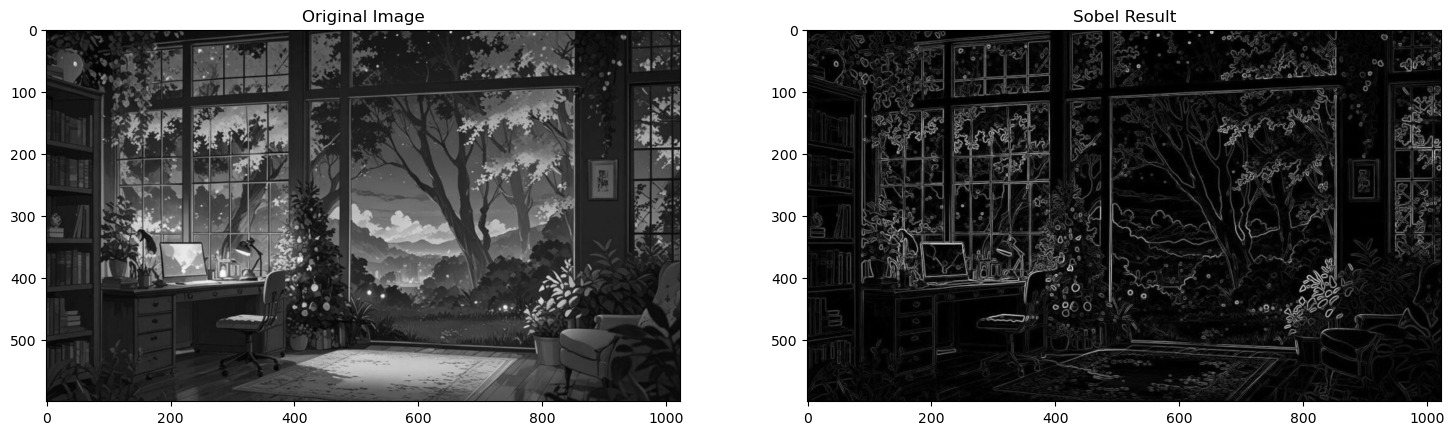

In [13]:
# Sobel Operator
# Sobel X -> Sobel(img, depth, dx, dy, ksize)
# depth -> formatting hasil angka setelah diturunin


# dx -> arah gradien horizontal (1 untuk horizontal/x, 0 untuk vertikal/y)
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, 3)  # Horizontal edges


# dy -> arah gradien vertikal (1 untuk vertikal/y, 0 untuk horizontal/x)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, 3)  # Vertical edges  


# ksize -> ukuran kernel (3, 5, atau 7) ganjil


# gabungin keduanya 
# Result

sobel_result = np.sqrt(sobel_x**2 + sobel_y**2)
# Sobel Operator
# Sobel-X -> Sobel(image, depth, dx, dy, ksize) 
# plt.subplot(1,2,1)
plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.imshow(img, 'gray')
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(sobel_result, 'gray')
plt.title('Sobel Result')

In [15]:
# Laplacian -> bisa detect semua arah
# (img, depth, ksize)

laplacian_result = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
laplacian_result = cv2.convertScaleAbs(laplacian_result) # formatted to uint8

result = np.hstack((img, laplacian_result))
cv2.imshow('Laplacian Result', result)
cv2.waitKey(0)

-1

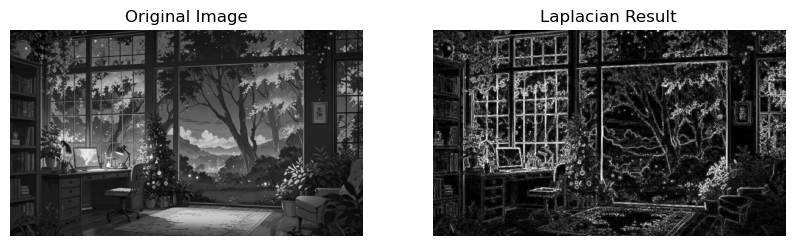

In [22]:
# Laplacian -> bisa detect semua arah
# Laplacian(image, depth, ksize)
laplacian_res = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
laplacian_res = cv2.convertScaleAbs(laplacian_res) # untuk mengubah hasil ke dalam bentuk uint8

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, 'gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(laplacian_res, 'gray')
plt.title('Laplacian Result')
plt.axis('off')

plt.show()

In [18]:
# Canny Edge Detection
# 1. Noise Reduction
# 2. Calculate intesity gradient
# 3. Supress False Edges
# 4. Tresholding

# (img, lower_treshold, upper_treshold)
canny_result = cv2.Canny(img, 100, 200)

cv2.imshow('Canny Result', canny_result)
cv2.waitKey(0)


-1

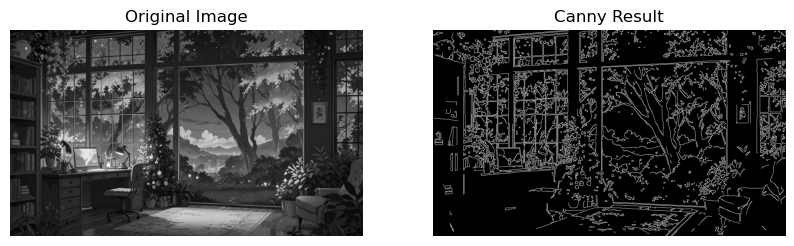

In [23]:
# Canny
# 1. Noise Reduction
# 2. Calculate intensity gradient
# 3. Supress False Edges
# 4. Thresholding

# Canny(image, lower_threshold, upper_threshold)
canny_res = cv2.Canny(img, 100, 200)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, 'gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(canny_res, 'gray')
plt.title('Canny Result')
plt.axis('off')
plt.show()

In [28]:
# tampilin semua hasil

sobel_result = cv2.convertScaleAbs(sobel_result) # untuk mengubah hasil ke dalam bentuk uint8
res_1 = np.hstack((img, sobel_result))
res_2 = np.hstack((laplacian_res, canny_res))
res_all = np.vstack((res_1, res_2))
cv2.imshow('All Results', res_all)
cv2.waitKey(0)


-1

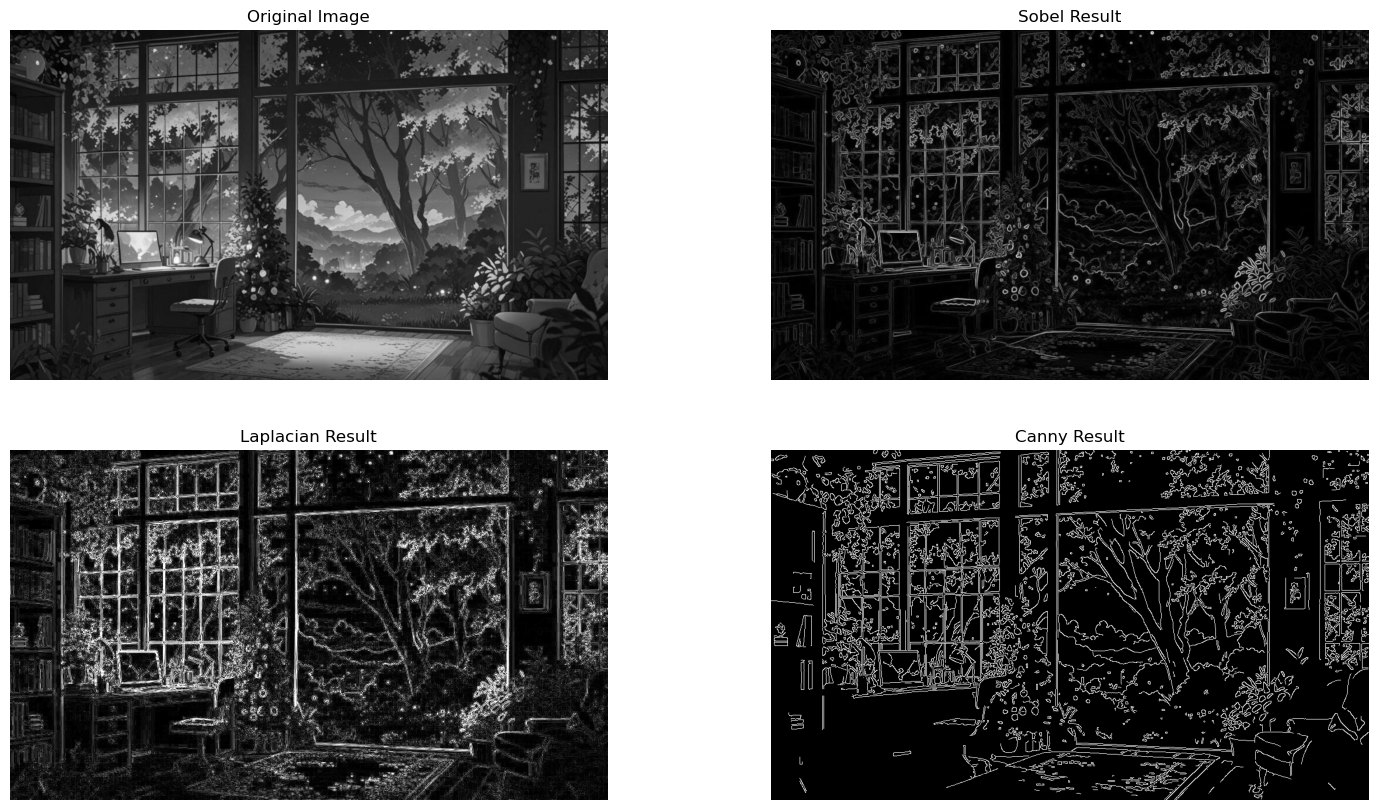

In [27]:
# All Results
plt.figure(figsize=(18,10))
plt.subplot(2,2,1)
plt.imshow(img, 'gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(sobel_result, 'gray')
plt.title('Sobel Result')
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(laplacian_res, 'gray')
plt.title('Laplacian Result')
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(canny_res, 'gray')
plt.title('Canny Result')
plt.axis('off')
plt.show()